# Data Science Mini Project

**Student Name:** Lokesh C

**Batch:** TN-DS-AN B03

**Project Title:** Analyzing Mental Health Trends Among Students

**Submission Date:** 

---

# 1. Problem Definition

## 1.1 Business / Real-World Problem Statement

>Student depression is a growing concern for educational institutions, as academic pressure, lifestyle factors, and personal circumstances can affect students’ mental well-being. Identifying students who may be at higher risk of depression can help institutions provide timely support and develop appropriate early intervention strategies.

---

## 1.2 Project Objectives

* Analyze demographic, academic, lifestyle, and behavioral patterns associated with student depression.
* Perform data preprocessing, exploratory data analysis, and feature selection to identify relevant factors.
* Build and evaluate multiple machine learning models for student depression prediction.
* Compare the performance of different classification models using appropriate evaluation metrics.
* Develop a reliable predictive model that can support early identification and intervention strategies.

---


## 1.3 Machine Learning Problem Type

Supervised Learning – Classification

Reason:  
The dataset contains a target variable indicating whether a student is experiencing depression. Since the goal is to predict a categorical outcome, this is a classification problem.

---

# 2. Dataset Understanding

## 2.1 Dataset Source

Dataset Source: <font color='blue'>**https://www.openml.org/search?type=data&status=active&id=46874**</font>


---

## 2.2 Dataset Description

* Number of rows: 1999
* Number of columns: 17
* Dataset purpose: To analyze demographic, academic, lifestyle, and behavioral factors associated with student depression and to build a machine learning model for predicting depression among students.
* Data collection source: OpenML

---

## 2.3 Feature Description

| Feature Name                         | Data Type   | Description                                                                     |
| ------------------------------------ | ----------- | ------------------------------------------------------------------------------- |
| Gender                               | Categorical | Gender of the student.                                                          |
| Age                                  | Numeric     | Age of the student.                                                             |
| City                                 | Categorical | City where the student is located.                                              |
| Profession                           | Categorical | Professional status of the student.                                             |
| Academic Pressure                    | Numeric     | Level of academic pressure experienced by the student.                          |
| Work Pressure                        | Numeric     | Level of work-related pressure experienced by the student.                      |
| CGPA                                 | Numeric     | Cumulative Grade Point Average representing the student's academic performance. |
| Study Satisfaction                   | Numeric     | Level of satisfaction the student has with their studies.                       |
| Job Satisfaction                     | Numeric     | Level of satisfaction the student has with their job or work.                   |
| Sleep Duration                       | Categorical | Approximate amount of sleep the student gets daily.                                   |
| Dietary Habits                       | Categorical | General dietary habits of the student.                                          |
| Degree                               | Categorical | Educational degree or program pursued by the student.                           |
| Have You Ever Had Suicidal Thoughts? | Categorical | Indicates whether the student has experienced suicidal thoughts.                |
| Work/Study Hours                     | Numeric     | Number of hours the student spends working or studying per day.                 |
| Financial Stress                     | Numeric     | Level of financial stress experienced by the student.                           |
| Family History of Mental Illness     | Categorical | Indicates whether the student has a family history of mental illness.           |

---

## 2.4 Target Variable (If Applicable)

Target Variable:

* Name: Depression
* Description: Indicates whether a student is experiencing depression.
* Prediction Goal: To predict whether a student is likely to be classified as depressed based on demographic, academic, lifestyle, and other relevant factors.

---

# 3. Exploratory Data Analysis (EDA)

## 3.1 Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, precision_score, recall_score, f1_score

## 3.2 Load Dataset

In [ ]:
df = pd.read_excel("Student health dataset.xlsx")

## 3.3 Dataset Overview

In [ ]:
df.head()

,Gender,Age,City,Professional,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,'5-6 hours',Healthy,B.Pharm,Yes,3,1,No,1
1,Female,24,Bangalore,Student,2,0,5.90,5,0,'5-6 hours',Moderate,BSc,No,3,2,Yes,0
2,Male,31,Srinagar,Student,3,0,7.03,5,0,'Less than 5 hours',Healthy,BA,No,9,1,Yes,0
3,Female,28,Varanasi,Student,3,0,5.59,2,0,'7-8 hours',Moderate,BCA,Yes,4,5,Yes,1
4,Female,25,Jaipur,Student,4,0,8.13,3,0,'5-6 hours',Moderate,M.Tech,Yes,1,1,No,0


In [ ]:
df.tail()

,Gender,Age,City,Professional,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
1994,Male,23,Faridabad,Student,2,0,6.78,3,0,'More than 8 hours',Healthy,BSc,Yes,10,3,Yes,1
1995,Female,24,Patna,Student,3,0,9.84,2,0,'5-6 hours',Moderate,M.Ed,No,7,5,Yes,1
1996,Male,25,Ghaziabad,Student,3,0,5.85,2,0,'7-8 hours',Unhealthy,B.Pharm,Yes,7,5,Yes,1
1997,Female,23,Ludhiana,Student,2,0,7.27,2,0,'Less than 5 hours',Healthy,B.Arch,No,2,5,No,0
1998,Male,32,Vasai-Virar,Student,3,0,6.51,2,0,'5-6 hours',Unhealthy,BSc,No,9,4,Yes,0


In [ ]:
df.columns

Index(['Gender', 'Age', 'City', 'Professional', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree', 'suicidal thoughts ?',
       'Work/Study Hours', 'Financial Stress',
       'Family History of Mental Illness', 'Depression'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1999 entries, 0 to 1998
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Gender                            1999 non-null   str    
 1   Age                               1999 non-null   int64  
 2   City                              1999 non-null   str    
 3   Professional                      1999 non-null   str    
 4   Academic Pressure                 1999 non-null   int64  
 5   Work Pressure                     1999 non-null   int64  
 6   CGPA                              1999 non-null   float64
 7   Study Satisfaction                1999 non-null   int64  
 8   Job Satisfaction                  1999 non-null   int64  
 9   Sleep Duration                    1999 non-null   str    
 10  Dietary Habits                    1999 non-null   str    
 11  Degree                            1999 non-null   str    
 12  suicidal thoughts

In [ ]:
df.describe()

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,1999.000000,1999.000000,1999.0,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000
mean,25.731866,3.156078,0.0,7.672886,2.924462,0.001501,7.173087,3.146573,0.586793
std,4.912665,1.396281,0.0,1.462781,1.356332,0.067099,3.737516,1.451597,0.492532
min,18.000000,1.000000,0.0,5.060000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,21.000000,2.000000,0.0,6.330000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,25.000000,3.000000,0.0,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,30.000000,4.000000,0.0,8.940000,4.000000,0.000000,10.000000,4.000000,1.000000
max,42.000000,5.000000,0.0,10.000000,5.000000,3.000000,12.000000,5.000000,1.000000


### Observations

* The dataset contains 1999 student records and 17 features.
* The dataset contains both numerical and categorical features, which need to be treated later.
* The Depression is the target column for this clasification problem.

---

## 3.4 Missing Value Analysis

In [ ]:
# CHECKING THE NULL VALUES
df.isnull().sum()

Gender                              0
Age                                 0
City                                0
Professional                        0
Academic Pressure                   0
Work Pressure                       0
CGPA                                0
Study Satisfaction                  0
Job Satisfaction                    0
Sleep Duration                      0
Dietary Habits                      0
Degree                              0
suicidal thoughts ?                 0
Work/Study Hours                    0
Financial Stress                    0
Family History of Mental Illness    0
Depression                          0
dtype: int64

### Observations

No missing values were found in any of the features, so no imputation technique was required.

---

## 3.5 Correlation Analysis

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

print('Correlation:')
correlation

Correlation:


,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
Age,1.000000,-0.080432,NaN,0.088037,0.031586,0.014887,-0.034625,-0.120818,-0.214808
Academic Pressure,-0.080432,1.000000,NaN,-0.083873,-0.130933,-0.002501,0.078068,0.137610,0.454801
Work Pressure,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CGPA,0.088037,-0.083873,NaN,1.000000,-0.020911,0.029940,-0.038396,-0.024072,-0.015197
Study Satisfaction,0.031586,-0.130933,NaN,-0.020911,1.000000,0.001246,-0.032667,-0.035810,-0.138899
Job Satisfaction,0.014887,-0.002501,NaN,0.029940,0.001246,1.000000,0.004951,0.028572,-0.026660
Work/Study Hours,-0.034625,0.078068,NaN,-0.038396,-0.032667,0.004951,1.000000,0.087666,0.218860
Financial Stress,-0.120818,0.137610,NaN,-0.024072,-0.035810,0.028572,0.087666,1.000000,0.368970
Depression,-0.214808,0.454801,NaN,-0.015197,-0.138899,-0.026660,0.218860,0.368970,1.000000


### Observations

* Some features show positive or negative relationships with Depression.
* Highly correlated features may provide useful information for model development.

## 3.6 Visualizations

### Visualization 1

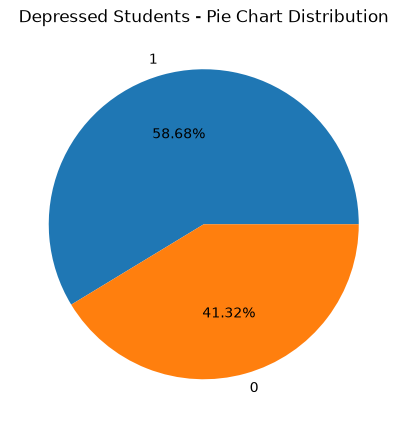

In [ ]:
depressed_count = df['Depression'].value_counts()
plt.figure(figsize=(5,7))
plt.pie(x=depressed_count.values, autopct='%1.2f%%', labels= depressed_count.index)
plt.title('Depressed Students - Pie Chart Distribution')
plt.show()

Observation:

The pie chart shows the distribution of depressed and non-depressed students in the dataset and it helps identify the proportion of each target class

---

### Visualization 2

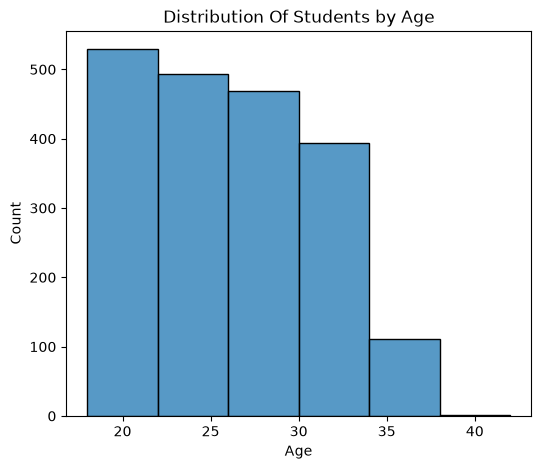

In [ ]:
plt.figure(figsize=(6,5))
sns.histplot(df,x=df['Age'], bins=6)
plt.title('Distribution Of Students by Age')
plt.show()

Observation:

* The histogram shows the age distribution of students in the dataset.
* Most students are concentrated within a 30 age group.

---

### Visualization 3

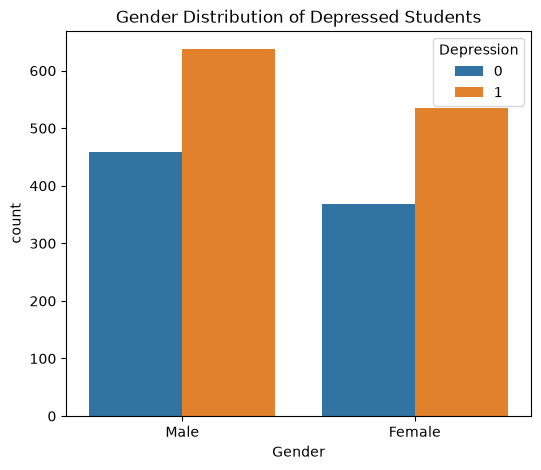

In [ ]:
plt.figure(figsize=(6,5))
sns.countplot(df,x=df['Gender'], hue=df['Depression'])
plt.title('Gender Distribution of Depressed Students')
plt.show()

Observation:

* The count plot shows the distribution of depression across different genders.
* It helps compare the number of depressed and non-depressed students within each gender

---

### Visualization 4

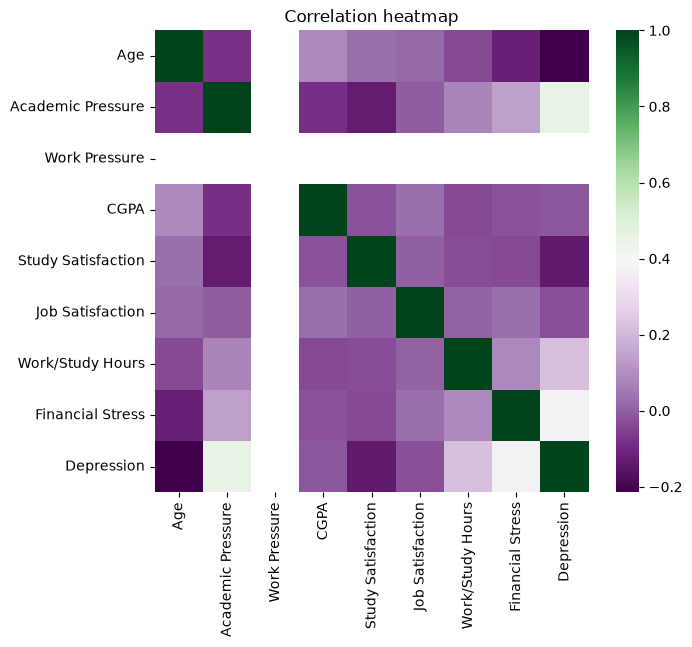

In [ ]:
plt.figure(figsize=(7,6))
sns.heatmap(data=correlation, cmap='PRGn')
plt.title('Correlation heatmap')
plt.show()

Observation:

* The heatmap shows the correlation between numerical features in the dataset.
* Darker shades indicate stronger relationships, while lighter shades indicate weaker relationships.
* The heatmap helps identify features that may have a stronger relationship with Depression.

---

### Visualization 5

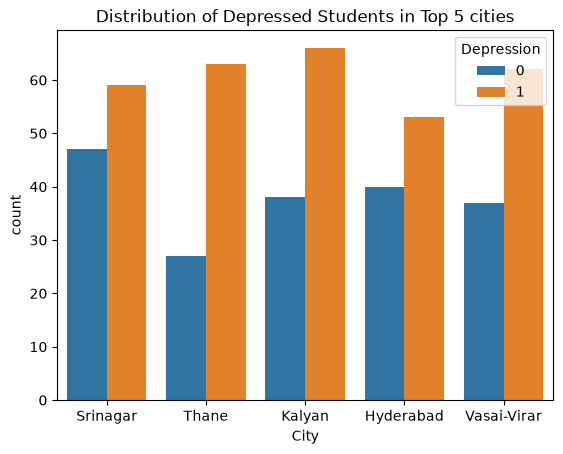

In [ ]:
top5_cities = df['City'].value_counts()[:5].index
df_top5 = df[df['City'].isin(top5_cities)]

plt.Figure(figsize=(10,8))
sns.countplot(data=df_top5, x='City', hue=df.Depression)
plt.title('Distribution of Depressed Students in Top 5 cities')
plt.show()

Observation:

* The count plot shows the depression distribution across the top 5 cities with the highest number of students.
* It compares depressed and non-depressed students in each city.

---

### Visualization 6

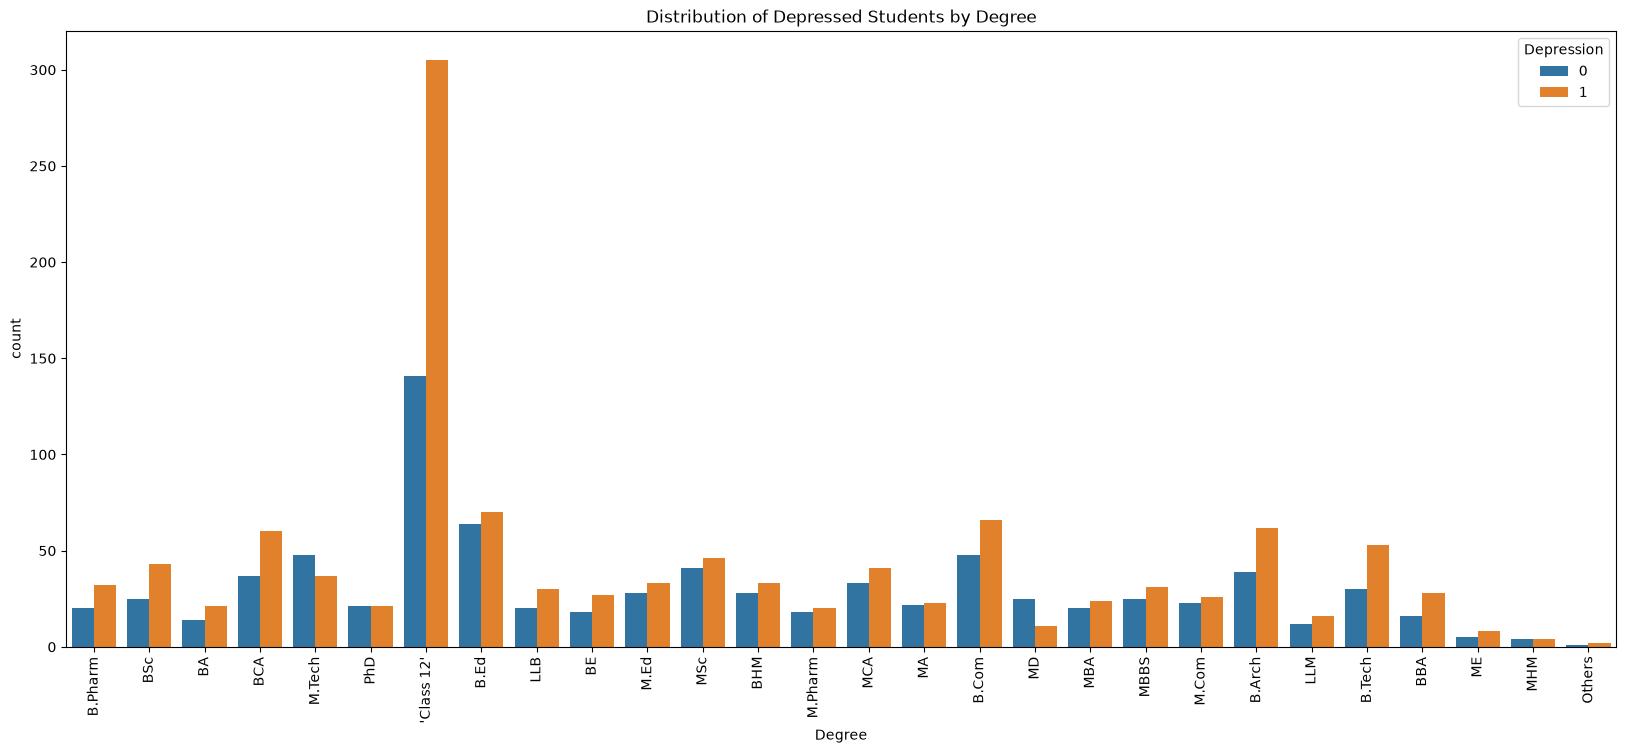

In [ ]:
plt.figure(figsize=(20,8))
sns.countplot(data=df, x='Degree', hue=df.Depression)
plt.title('Distribution of Depressed Students by Degree')
plt.xticks(rotation=90)
plt.show()

Observation:

* The count plot shows the distribution of depression across different degree programs.
* We can see that the Class 12 have more number of Depressed Students

---

### Visualization 7

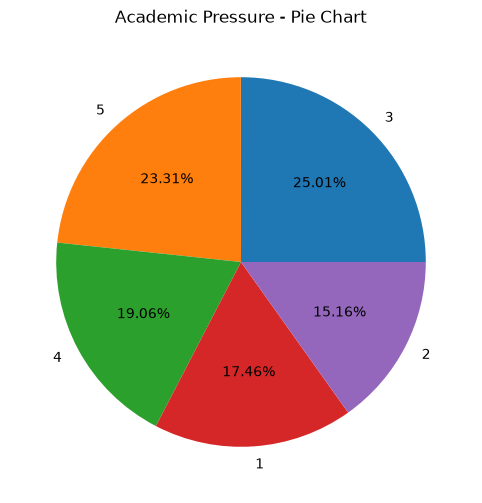

In [ ]:
academic_pressure = df['Academic Pressure'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(academic_pressure.values, labels=academic_pressure.index, autopct="%1.2f%%" )
plt.title('Academic Pressure - Pie Chart')
plt.show()

Observation:

The pie chart shows the distribution of students across different levels of academic pressure.

---

### Visualization 8

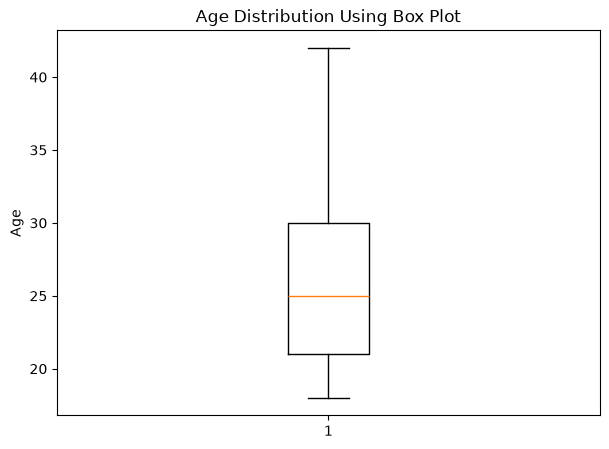

In [ ]:
plt.figure(figsize=(7, 5))

plt.boxplot(df["Age"])
plt.ylabel("Age")
plt.title("Age Distribution Using Box Plot")
plt.show()

Observation:

* The box plot shows the distribution and spread of students' ages.
* The median age and overall age range can be observed from the plot.

---

## 3.7 Key Insights from EDA

* The Depression variable contains both depressed and non-depressed students in balanced distribution.
* Correlation analysis shows that some numerical features have stronger relationships with the target than others and the Financial Stress and Work Pressure columns shows no relationship with the target(Depression)
* The Age box plot shows the overall spread of student ages and no outliers present in that chart.

---

# 4. Data Preprocessing

## 4.1 Missing Value Treatment

In [ ]:
df.isnull().sum()

Gender                              0
Age                                 0
City                                0
Professional                        0
Academic Pressure                   0
Work Pressure                       0
CGPA                                0
Study Satisfaction                  0
Job Satisfaction                    0
Sleep Duration                      0
Dietary Habits                      0
Degree                              0
suicidal thoughts ?                 0
Work/Study Hours                    0
Financial Stress                    0
Family History of Mental Illness    0
Depression                          0
dtype: int64

Justification:  

There is no null values present in the dataset, so imputation treatment is not required

---

## 4.2 Duplicate Handling

In [ ]:
# CHECKING THE DUPLICATES
df.duplicated().sum()

np.int64(0)

Observation:  

There is no Duplicates was observed in the dataset

---

## 4.3 Outlier Detection and Treatment

### Boxplot

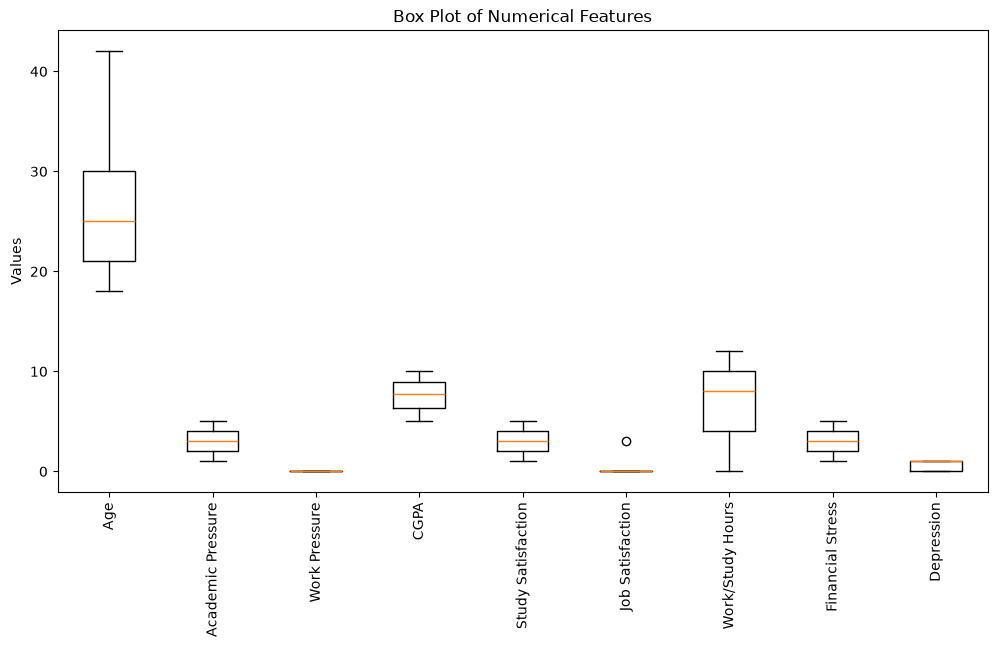

In [ ]:
numeric_columns = df.select_dtypes('number').columns

plt.figure(figsize=(12, 6))
plt.boxplot([df[col] for col in numeric_columns], tick_labels=numeric_columns)

plt.title('Box Plot of Numerical Features')
plt.xticks(rotation=90)
plt.ylabel('Values')

plt.show()

### IQR Method

In [ ]:
# Outlier treatment

# IQR

Q1 = df['Job Satisfaction'].quantile(0.25)
Q3 = df['Job Satisfaction'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df.drop(df[(df['Job Satisfaction']<lower_bound ) | (df['Job Satisfaction']>upper_bound)].index, inplace=True)

df.reset_index(inplace=True)

Observation:

* The box plot shows that most numerical features have no major extreme outliers.
* Job Satisfaction contains a noticeable outlier.
* The remaining numerical features, including Age, Academic Pressure, CGPA, Study Satisfaction, Work/Study Hours, and Financial Stress, appear to have values within their expected ranges.

---


## 4.4 Skewness Treatment

### Before Transformation

In [ ]:
skewness = df[numeric_columns].skew()
skewness.abs().sort_values(ascending=False)

Work/Study Hours      0.454109
Depression            0.354021
Academic Pressure     0.150589
Financial Stress      0.135623
Age                   0.129021
CGPA                  0.091452
Study Satisfaction    0.027545
Work Pressure         0.000000
Job Satisfaction      0.000000
dtype: float64

Observations:
* Work/Study Hours has the highest skewness (0.454), indicating a slight positive skew.
* Depression has a skewness of 0.354, showing a slight imbalance in its numerical representation.
* Academic Pressure, Financial Stress, Age, and CGPA have relatively low skewness values, indicating nearly symmetric distributions.
* Study Satisfaction has very low skewness (0.028), while Work Pressure and Job Satisfaction have 0 skewness, indicating symmetric distributions.
* Overall, the numerical features show low to moderate skewness, so no major skewness treatment appears necessary.

---

In [ ]:
bachelor = ['B.Pharm', 'BSc', 'BA', 'BHM', 'BCA', 'B.Ed', 'LLB', 'BE', 'M.Ed', 'BHM', 'B.Com', 'B.Arch', 'B.Tech', 'BBA']
masters = ['M.Tech', 'M.Ed', 'MSc', 'M.Pharm', 'MCA','MA', 'MD', 'MBA', 'MBBS', 'M.Com','LLM','ME','MHM','Others']
doc = ['PhD']
school = ["'Class 12'"]

df.loc[df['Degree'].isin(bachelor), 'Degree'] = 'Under-Graduate'
df.loc[df['Degree'].isin(masters),'Degree'] = 'Post-Graduate'
df.loc[df['Degree'].isin(doc), 'Degree' ]= 'Doctorate'
df.loc[df['Degree'].isin(school), 'Degree'] = 'School'

Before proceeding to Encoding Degree categories were grouped into educational levels such as UnderGraduate, PostGraduate to reduce category fragmentation and simplify the feature representation.

## 4.5 Encoding

### Label Encoding

In [ ]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['suicidal thoughts ?'] = le.fit_transform(df['suicidal thoughts ?'])
df['Family History of Mental Illness'] = le.fit_transform(df['Family History of Mental Illness'])

### For ordinal data

In [ ]:
df['Sleep Duration'] = df['Sleep Duration'].map({"'Less than 5 hours'": 0,"'5-6 hours'": 1, "'7-8 hours'": 2, "'More than 8 hours'": 3, 'Others': 4 })
df['Dietary Habits'] = df['Dietary Habits'].map({'Healthy': 2, 'Moderate' : 1, 'Unhealthy': 0})
df['Degree'] = df['Degree'].map({'Under-Graduate' : 1, 'Post-Graduate' : 2, 'Doctorate' : 3, 'School' : 0})

### One Hot Encoding

In [ ]:
one_hot = pd.get_dummies(df['City'], dtype=int, prefix='City')

df = pd.concat([df, one_hot], axis=1, )



---

# 5. Feature Engineering & Feature Selection

## 5.1 Feature Engineering

In [ ]:
df = df.drop(df[['index','City','Professional']], axis=1)

Observations: Removed the unwanted columns

## 5.2 Correlation-Based Feature Selection

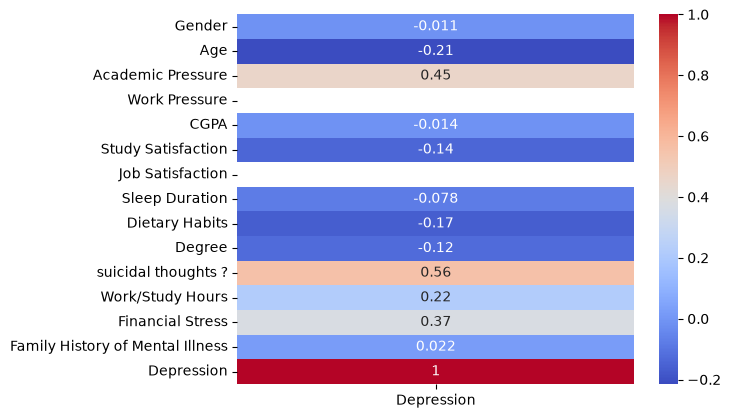

In [ ]:
corr = df.corr(numeric_only=True)['Depression'][:15]
plt.Figure(figsize=(12,10))
sns.heatmap(corr.to_frame(), cmap='coolwarm',annot=True)
plt.title('')
plt.show()

In [ ]:
X = df.drop(df[['Work Pressure','Job Satisfaction','Depression']], axis=1)
y = df['Depression']

Observation:

After observing the correlation chart, features which has no relationship with the Traget were removed

---

## 4.7 Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

## 5.3 SelectKBest

In [ ]:
selector = SelectKBest(score_func=chi2, k = 20)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

Observation:

SelectKBest with the Chi-Square (χ²) statistical test was used to select the 20 most relevant features for the classification model.

* The feature selector was fitted only on the training data to prevent data leakage.
* The same selected features were then applied to the test data.
* This helps reduce unnecessary features and retain the features most relevant to the target variable.

---

## 5.4 Final Feature Set

In [ ]:
selected_features = X_train.columns[selector.get_support()]
selected_features

Index(['Age', 'Academic Pressure', 'Study Satisfaction', 'Sleep Duration',
       'Dietary Habits', 'Degree', 'suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'City_Agra', 'City_Ahmedabad', 'City_Delhi',
       'City_Jaipur', 'City_Kanpur', 'City_Lucknow', 'City_Mumbai',
       'City_Patna', 'City_Pune', 'City_Thane', 'City_Visakhapatnam'],
      dtype='str')

These Features were selected for the ML Model Training


## 4.6 Feature Scaling

### Standardization

In [ ]:
# Feature Scaling

scale = StandardScaler()

X_train_Scaled = scale.fit_transform(X_train_selected, y_train)
X_test_Scaled =  scale.transform(X_test_selected)

StandardScaler was used to standardize the selected features.

* Scaling was performed after the train-test split to prevent data leakage.
* The scaler was fitted only on the training data.
* The same fitted scaler was then applied to the test data

---

# 6. Model Building

---

## 6.1 Logistic Regression

In [ ]:
lr = LogisticRegression(penalty='l2')

lr.fit(X_train_Scaled,y_train)

lr_pred = lr.predict(X_test_Scaled)
lr_prob = lr.predict_proba(X_test_Scaled)[:,1]

c:\Users\USER2\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


---

## 6.2 Decision Tree Classifier

In [ ]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_Scaled,y_train)

dt_pred = dt.predict(X_test_Scaled)
dt_prob = dt.predict_proba(X_test_Scaled)[:,1]

---

## 6.3 Random Forest Classifier

In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_train_Scaled,y_train)

rf_pred = rf.predict(X_test_Scaled)
rf_prob = rf.predict_proba(X_test_Scaled)[:,1]

---

## 6.4 XGBClassifier

In [ ]:
xg = XGBClassifier(max_depth=4, learning_rate=0.1, n_estimators=100)
xg.fit(X_train_Scaled,y_train)

xg_pred = xg.predict(X_test_Scaled)
xg_prob = xg.predict_proba(X_test_Scaled)[:,1]

---

## 6.5 KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_Scaled,y_train)

knn_pred = knn.predict(X_test_Scaled)
knn_prob = knn.predict_proba(X_test_Scaled)[:,1]

---

## 6.6 SVC

In [ ]:
svc = SVC(C=1, kernel='rbf', gamma='scale')
svc.fit(X_train_Scaled, y_train)

svc_pred = svc.predict(X_test_Scaled)
svc_score = svc.decision_function(X_test_Scaled)

---

**Results:**


# 7. Model Evaluation & Comparison

## 7.1 Evaluation Metrics

In [ ]:
print('='*55)
print('LOGISTIC REGRESSION - Model Evaluation')
print('='*55)
print('Accuracy:\t',accuracy_score(lr_pred,y_test))
print('\nClassification Report:\n',classification_report(lr_pred,y_test))
print('ROC-AUC:\t',roc_auc_score(y_test, lr_prob))

print('\n', '---'*30,'\n')

LOGISTIC REGRESSION - Model Evaluation
Accuracy:	 0.8225

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.81      0.78       154
           1       0.87      0.83      0.85       246

    accuracy                           0.82       400
   macro avg       0.81      0.82      0.81       400
weighted avg       0.83      0.82      0.82       400

ROC-AUC:	 0.9011476466795615

 ------------------------------------------------------------------------------------------ 



In [ ]:
print('='*55)
print('DECISION TREE - Model Evaluation')
print('='*55)
print('Accuracy:\t',accuracy_score(dt_pred,y_test))
print('\nClassification Report:\n',classification_report(dt_pred,y_test))
print('ROC-AUC:\t',roc_auc_score(y_test, dt_prob))

print('---'*30,'\n')

DECISION TREE - Model Evaluation
Accuracy:	 0.815

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.81      0.76       149
           1       0.88      0.82      0.85       251

    accuracy                           0.81       400
   macro avg       0.80      0.81      0.81       400
weighted avg       0.82      0.81      0.82       400

ROC-AUC:	 0.8568665377176016
------------------------------------------------------------------------------------------ 



In [ ]:
print('='*55)
print('RANDOM FOREST - Model Evaluation')
print('='*55)
print('Accuracy:\t',accuracy_score(rf_pred,y_test))
print('\nClassification Report:\n',classification_report(rf_pred,y_test))
print('ROC-AUC:\t',roc_auc_score(y_test, rf_prob))

print('\n','---'*30,'\n')

RANDOM FOREST - Model Evaluation
Accuracy:	 0.835

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.84      0.79       147
           1       0.90      0.83      0.86       253

    accuracy                           0.83       400
   macro avg       0.82      0.84      0.83       400
weighted avg       0.84      0.83      0.84       400

ROC-AUC:	 0.8920438426821405

 ------------------------------------------------------------------------------------------ 



In [ ]:
print('='*55)
print('XGBOOST - Model Evaluation')
print('='*55)
print('Accuracy:\t',accuracy_score(xg_pred,y_test))
print('\nClassification Report:\n',classification_report(xg_pred,y_test))
print('ROC-AUC:\t',roc_auc_score(y_test, xg_prob))

print('\n','---'*30,'\n')

XGBOOST - Model Evaluation
Accuracy:	 0.8175

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.80      0.77       152
           1       0.87      0.83      0.85       248

    accuracy                           0.82       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.82      0.82      0.82       400

ROC-AUC:	 0.8871695680206318

 ------------------------------------------------------------------------------------------ 



In [ ]:
print('='*55)
print('K-NEAREST NEIGHBOURS - Model Evaluation')
print('='*55)
print('Accuracy:\t',accuracy_score(knn_pred,y_test))
print('\nClassification Report:\n',classification_report(knn_pred,y_test))
print('ROC-AUC:\t',roc_auc_score(y_test, knn_prob))

print('\n','---'*30,'\n')

K-NEAREST NEIGHBOURS - Model Evaluation
Accuracy:	 0.775

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.74      0.72       155
           1       0.83      0.80      0.81       245

    accuracy                           0.78       400
   macro avg       0.76      0.77      0.77       400
weighted avg       0.78      0.78      0.78       400

ROC-AUC:	 0.8361444229529336

 ------------------------------------------------------------------------------------------ 



In [ ]:
print('='*55)
print('SUPPORT VECTOR CLASSIFIER - Model Evaluation')
print('='*55)
print('Accuracy:\t',accuracy_score(svc_pred,y_test))
print('\nClassification Report:\n',classification_report(svc_pred,y_test))
print('ROC-AUC:\t',roc_auc_score(y_test, svc_score))

print('\n','---'*30,'\n')

SUPPORT VECTOR CLASSIFIER - Model Evaluation
Accuracy:	 0.82

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.80      0.78       157
           1       0.86      0.84      0.85       243

    accuracy                           0.82       400
   macro avg       0.81      0.82      0.81       400
weighted avg       0.82      0.82      0.82       400

ROC-AUC:	 0.8838426821405544

 ------------------------------------------------------------------------------------------ 



---

## 7.2 Model Comparison Table

In [ ]:
metric = {"accuracy_score":[],
          'precision':[],
          'recall':[],
          'f1-score':[],
          'ROC-AUC':[]}

In [ ]:
model_pred = [lr_pred, dt_pred, rf_pred, xg_pred, knn_pred, svc_pred]
model_prob = [lr_prob, dt_prob, rf_prob, xg_prob, knn_prob, svc_score]

for i in model_pred:
    metric['accuracy_score'].append(np.round(accuracy_score(i,y_test),2))
    metric['precision'].append(np.round(precision_score(i,y_test), 2))
    metric['recall'].append(np.round(recall_score(i, y_test),2))
    metric['f1-score'].append(np.round(f1_score(i, y_test),2))
    i+=1

for i in model_prob:
    metric['ROC-AUC'].append(np.round(roc_auc_score(y_test, i),2))
    i+=1
print("\t \t*****  MODEL COMPARISION TABLE  *****\n")
pd.DataFrame(metric, index=['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'KNN','SVC'])

	 	*****  MODEL COMPARISION TABLE  *****



,accuracy_score,precision,recall,f1-score,ROC-AUC
Logistic Regression,0.82,0.87,0.83,0.85,0.90
Decision Tree,0.82,0.88,0.82,0.85,0.86
Random Forest,0.84,0.90,0.83,0.86,0.89
XGBoost,0.82,0.87,0.83,0.85,0.89
KNN,0.78,0.83,0.80,0.81,0.84
SVC,0.82,0.86,0.84,0.85,0.88


----

## 7.4 Overfitting / Underfitting Analysis

In [ ]:
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xg,
    "KNN": knn,
    "SVC": svc
}

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

results = []

for name, model in models.items():

    model.fit(X_train_Scaled, y_train)

    y_train_pred = model.predict(X_train_Scaled)
    y_test_pred = model.predict(X_test_Scaled)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    results.append({
        "Model": name,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Accuracy Gap": train_accuracy - test_accuracy,

    })

results_df = pd.DataFrame(results)

results_df.sort_values(by='Accuracy Gap', ascending=True)

c:\Users\USER2\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,Model,Train Accuracy,Test Accuracy,Accuracy Gap
0,Logistic Regression,0.841677,0.8225,0.019177
1,Decision Tree,0.852315,0.8150,0.037315
2,Random Forest,0.876721,0.8350,0.041721
5,SVC,0.876095,0.8200,0.056095
3,XGBoost,0.903630,0.8175,0.086130
4,KNN,0.865457,0.7750,0.090457


Observation:  

Logistic Regression generalizes best, while KNN and XGBoost show the strongest signs of overfitting. Random Forest has some overfitting, but its gap remains relatively moderate.

---

## 7.3 Best Model Selection

Among the six classification models evaluated, **Random Forest** was selected as the final model.

* Random Forest achieved the highest test accuracy (0.84) and the highest F1-score (0.86) among the evaluated models.
* It also achieved the highest precision (0.90), indicating that its positive predictions were comparatively reliable.

---

# 8. Deployment

In [ ]:
import joblib

joblib.dump(rf, "random_forest_model.pkl")
joblib.dump(selector, "selector.pkl")
joblib.dump(scale, "scale.pkl")

feature_columns = X.columns.tolist()
joblib.dump(feature_columns, "feature_columns.pkl")

print("Model saved successfully!")

Model saved successfully!
